<a href="https://colab.research.google.com/github/midorij347/KdV_simulation/blob/main/KdV_equetion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

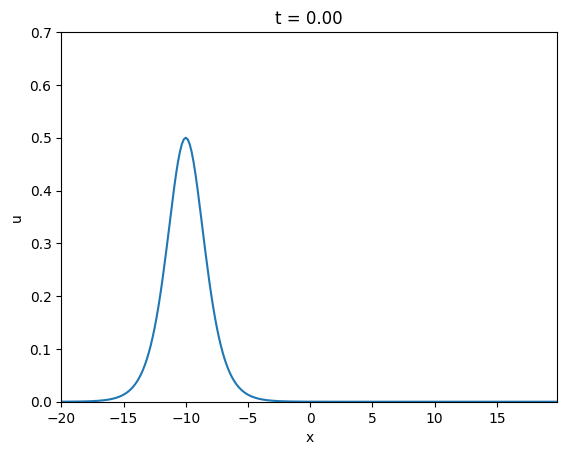

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from scipy.integrate import solve_ivp

L = 40.0
N = 256
x = np.linspace(-L/2, L/2, N, endpoint=False)
dx = x[1] - x[0]
k = 2 * np.pi * np.fft.fftfreq(N, d=dx)

c = 1.0
x0 = -10.0
u0 = 0.5 * c * (1 / np.cosh(np.sqrt(c)/2 * (x - x0)))**2

def kdv_rhs(t, u):
    u_hat = np.fft.fft(u)
    ux = np.fft.ifft(1j * k * u_hat).real
    uxxx = np.fft.ifft((1j * k)**3 * u_hat).real
    return -uxxx + 6 * u * ux

t_eval = np.linspace(0.0, 4.0, 200)
sol = solve_ivp(kdv_rhs, (0.0, 4.0), u0, t_eval=t_eval, method="RK45")

fig, ax = plt.subplots()
line, = ax.plot(x, sol.y[:, 0])
ax.set_xlim(x.min(), x.max())
ax.set_ylim(0, 0.7)
ax.set_xlabel("x")
ax.set_ylabel("u")

def update(frame):
    line.set_ydata(sol.y[:, frame])
    ax.set_title(f"t = {sol.t[frame]:.2f}")
    return line,

ani = FuncAnimation(fig, update, frames=len(sol.t), interval=50, blit=True)
plt.show()